In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [71]:
#import and inspect data
spam_df = pd.read_csv("spam.csv")
spam_df.groupby('Category').describe()
#data set for 

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [72]:
import pandas as pd
import numpy as np
#uncomment the line bellow to import spambase
#!pip install ucimlrepo
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


In [73]:
# turning raw data into numarical data, creating a new collumn called spam
spam_df['spam'] = spam_df['Category'].apply(lambda x: 1 if x =='spam' else 0)

In [74]:
spam_df

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will ü b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [75]:
#creating and training
x_train,x_test,y_train,y_test = train_test_split(spam_df.Message,spam_df.spam,test_size = 0.25)

In [76]:
x_train.describe()


count                       4179
unique                      3908
top       Sorry, I'll call later
freq                          25
Name: Message, dtype: object

In [77]:
y_train.describe() #description for the spam collumn 

count    4179.000000
mean        0.134482
std         0.341210
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: spam, dtype: float64

In [78]:
#find word count and store data
cv = CountVectorizer()


x_train_count = cv.fit_transform(x_train.values)
cv
#x_train_count.toarray() 

CountVectorizer()

In [79]:
#train model
model = MultinomialNB()
#our naive bayes
model.fit(x_train_count, y_train)

MultinomialNB()

In [57]:
#pretest
email_ham = ["wanna meet up for the game?"]
email_ham_count = cv.transform(email_ham)
model.predict(email_ham_count)

array([0], dtype=int64)

In [58]:
email_spam = ["reward money click"]
email_spam_count = cv.transform(email_spam)
print(email_spam_count)
model.predict(email_spam_count)

  (0, 1803)	1
  (0, 4403)	1
  (0, 5539)	1


array([1], dtype=int64)

In [59]:
messageText = ["x"]
message_count =cv.transform(messageText)


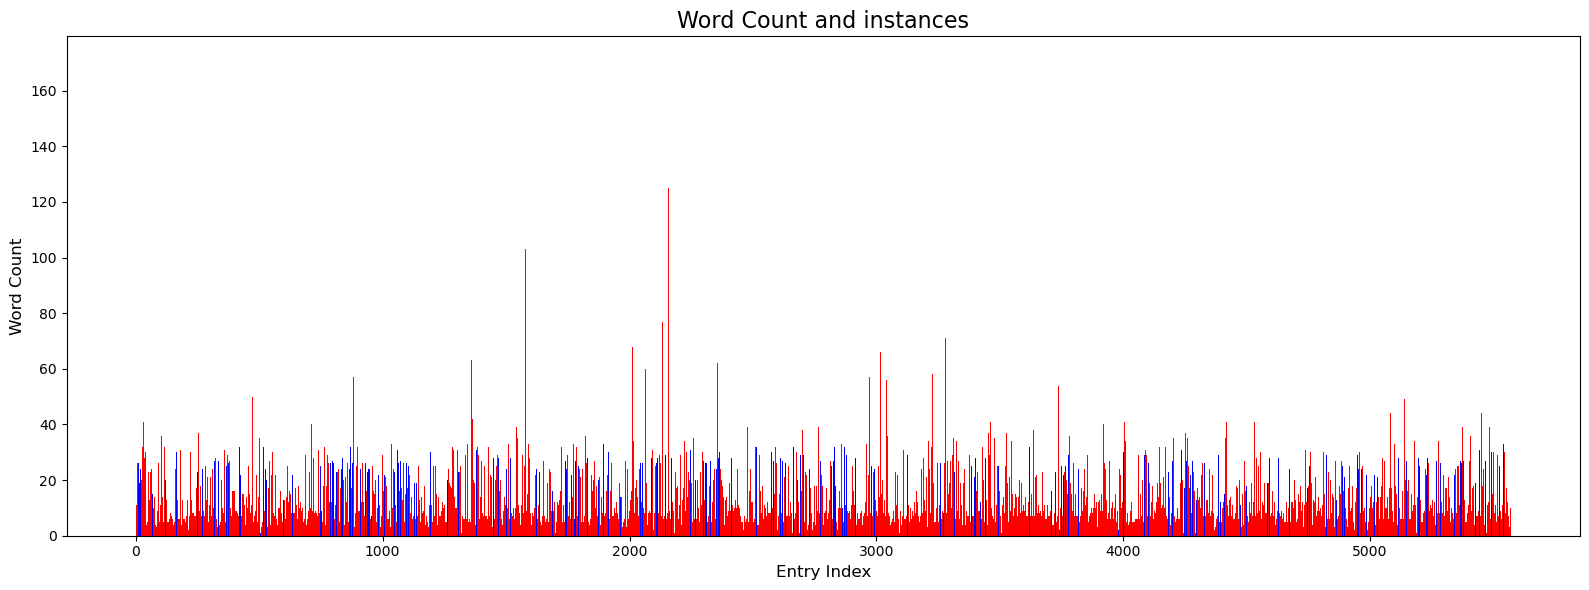

0       20
1        6
2       28
3       11
4       13
        ..
5567    30
5568     8
5569    10
5570    26
5571     6
Name: wordCount, Length: 5572, dtype: int64

In [81]:

spam_df['wordCount'] = spam_df['Message'].apply(lambda x: len(str(x).split()))

# Display the first few rows of the updated dataframe
#print(spam_df.head())

import matplotlib.pyplot as plt
# Map colors based on category (ham = red, spam = gray)
colors = spam_df['Category'].map({'ham': 'red', 'spam': 'blue'})

# Create a bar graph
plt.figure(figsize=(16, 6))
plt.bar(range(len(spam_df)), spam_df['wordCount'], color=colors, width=1)

# Add labels and title
plt.title("Word Count and instances", fontsize=16)
plt.xlabel("Entry Index", fontsize=12)
plt.ylabel("Word Count", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()
spam_df['wordCount']

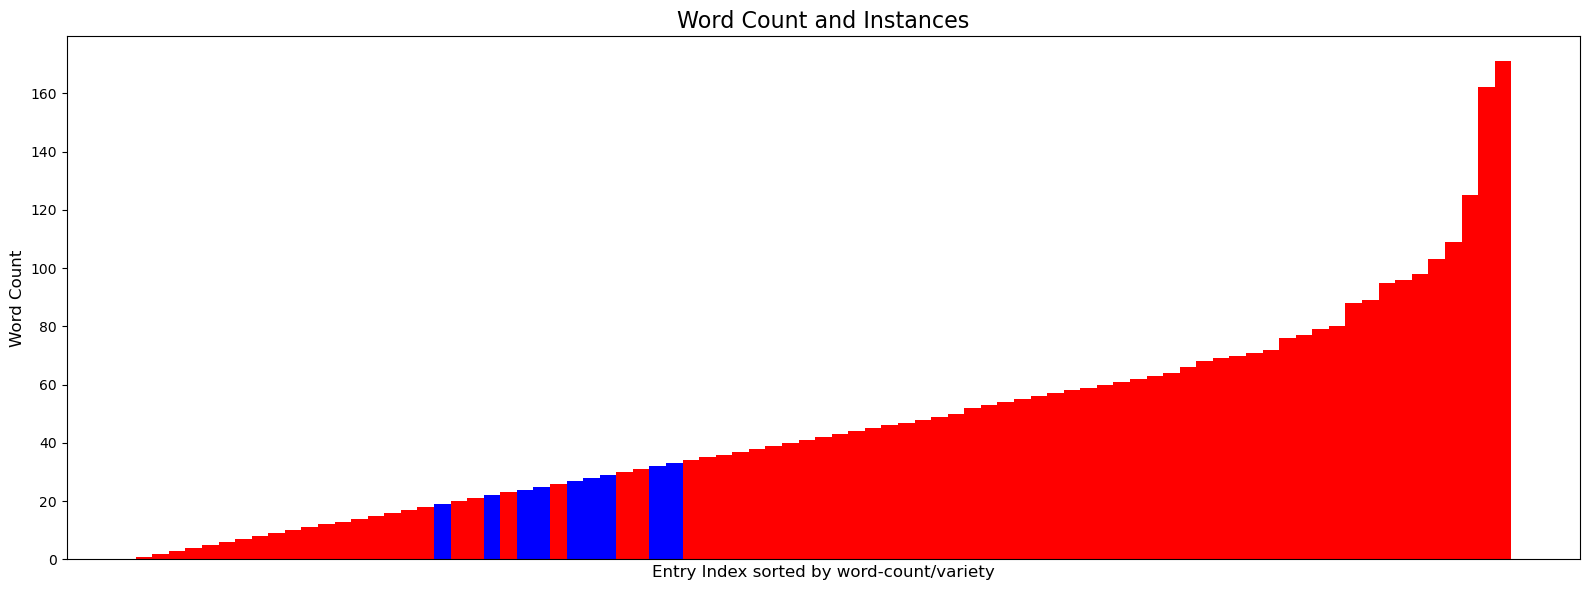

In [61]:
#skip this
# Compute the word count for each message
spam_df['wordCount'] = spam_df['Message'].apply(lambda x: len(str(x).split()))

# Remove duplicate word counts (keep the first occurrence)
spam_df = spam_df.drop_duplicates(subset=['wordCount'])

# Sort the dataframe by wordCount in ascending order
spam_df = spam_df.sort_values(by='wordCount', ascending=True)

# Map colors based on category (ham = red, spam = blue)
import matplotlib.pyplot as plt
colors = spam_df['Category'].map({'ham': 'red', 'spam': 'blue'})

# Create a bar graph
plt.figure(figsize=(16, 6))
plt.bar(range(len(spam_df)), spam_df['wordCount'], color=colors, width=1)

# Add labels and title
plt.title("Word Count and Instances", fontsize=16)
plt.xlabel("Entry Index sorted by word-count/variety", fontsize=12)
plt.ylabel("Word Count", fontsize=12)

# Remove x-axis indices (tick labels)
plt.xticks([])

# Display the plot
plt.tight_layout()
plt.show()


In [62]:
#working test

email_ham = ["wanna meet up for the game?"]
email_ham_count = cv.transform(email_ham)
model.predict(email_ham_count)




array([0], dtype=int64)

In [63]:
email_spam = ["reward money click"]
email_spam_count = cv.transform(email_spam)
print(email_spam_count)
model.predict(email_spam_count)

  (0, 1803)	1
  (0, 4403)	1
  (0, 5539)	1


array([1], dtype=int64)

In [82]:
allHam = spam_df[spam_df['Category'] == "ham"]
allHam.wordCount.mean() #average wordcount per real meassages

14.310259067357514

In [65]:
hamDeviation = np.std(allHam.wordCount)
hamDeviation

34.916774681048366

In [83]:
allSpam = spam_df[spam_df['Category'] == "spam"]
allSpam.wordCount.mean()


23.812583668005356

In [84]:
spamDeviation = np.std(allSpam.wordCount)
spamDeviation

5.952934739499953

In [85]:
len(spam_df[spam_df['Category'] == "ham"]), len(spam_df[spam_df['Category'] == "spam"])

(4825, 747)

In [93]:
spamDeviation*spamDeviation/hamDeviation*hamDeviation

35.43743201274537